# Functions

In [179]:
# In medical data, median is better than mean (because of lots of outliers)

def numerics_fill_na(df, col):
    print(f"Number of nan values in {col}:", len(df[df[col].isna()]["index"]))

    # Fill the missing values with median value
    med_val = df[col].median()
    print(f"Median in {col} =", med_val)
    
    df[col] = df[col].fillna(med_val)
    
    print(f"Number of nan values in {col} after handling:", len(df[df[col].isna()]["index"]))
    return df

In [180]:
def categoricals_fill_na(df, col):
    # convert type to category
    df[col] = df[col].astype('category')
    
    print(f"Number of nan values in {col}:", len(df[df[col].isna()]["index"]))

    # Fill the missing values with median value
    mod_val = df[col].mode()[0]
    print(f"Mode in {col} =", mod_val)
    
    df[col] = df[col].fillna(mod_val)
    
    print(f"Number of nan values in {col} after handling:", len(df[df[col].isna()]["index"]))
    return df

In [181]:
import matplotlib.pyplot as plt

def plot_histogram(df, col, w):
    value_counts = df[col].value_counts().sort_index()
    plt.figure(figsize=(8, 4))
    plt.bar(value_counts.index, value_counts.values, width=w, edgecolor='black')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title(f'{col}')
    plt.show()

In [182]:
import seaborn as sns

def plot_dots(df, col):
    sns.stripplot(x=df[col], size=4)
    plt.show()

In [183]:
def remove_outliers(df, col, k):

    col_clean = df[col].dropna()

    Q1 = col_clean.quantile(0.25)
    Q3 = col_clean.quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    
    # TEMPORARY filtered values
    filtered_vals = col_clean[(col_clean >= lower) & (col_clean <= upper)]

    # new dataframe to see changes after temporarily removing outliers for future calculations
    df_temp = df[(df[col] >= lower) & (df[col] <= upper)]

    return filtered_vals, df_temp

In [184]:
import numpy as np

def find_threshold(filtered_vals):

    # 1. Sort unique values of this column (after filtering outliers)
    unique_vals = np.sort(filtered_vals.unique())
    
    # 2. Find distance between values 
    gaps = np.diff(unique_vals)
    
    # 3. Find the index of maximum distance
    max_gap_idx = np.argmax(gaps)
    
    # 4. Find values before and after this gap
    lower = unique_vals[max_gap_idx]
    upper = unique_vals[max_gap_idx + 1]
    
    # 5. the threshold could be considered in the middle of these two points
    threshold = (lower + upper) / 2  
    
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    print(f"Suggested Threshold: {threshold}")

    return threshold

# Load & Merge 4 data

In [185]:
import pandas as pd

files = ['cleaned_data/abn1_cleaned.csv', 'cleaned_data/abn2_cleaned.csv',
         'cleaned_data/n1_cleaned.csv', 'cleaned_data/n2_cleaned.csv', 'cleaned_data/n3_cleaned.csv']
df_list = [pd.read_csv(f) for f in files]

df = pd.concat(df_list, ignore_index=True)

print(df.shape)

(1824, 70)


# Remove Records with NaN Label

In [186]:
# Check rows without label
print("-- Check Delivery Method")
print(df[df["delivery_method"].isna()]["index"])

-- Check Delivery Method
1254     34
1329    110
1367    151
1368    152
1370    155
1412    200
1455    247
1503    300
1526    325
1571    373
1804    620
Name: index, dtype: int64


In [187]:
mask = df["delivery_method"].isna()
df = df.loc[~mask].reset_index(drop=True)

df.shape

(1813, 70)

In [188]:
df['delivery_method'] = df['delivery_method'].astype('category')

# Drop Duplicates

In [189]:
# find rows with identical values (except index) and keep one of duplicates

duplicates = df[df.duplicated(subset=df.columns.difference(['index']), keep=False)]
print('number of duplicates BEFORE process', duplicates.shape[0])

df = df.drop_duplicates(subset=df.columns.difference(['index']))

duplicates = df[df.duplicated(subset=df.columns.difference(['index']), keep=False)]
print('number of duplicates AFTER process', duplicates.shape[0])

number of duplicates BEFORE process 325
number of duplicates AFTER process 0


In [190]:
df.shape

(1650, 70)

In [191]:
# Re-index dataframe (avoiding duplicated indexes)
df["index"] = range(1, len(df) + 1)
df.head()

,index,id,moth_age,moth_weight,moth_height,parent_relat,race,num_preg,num_births,num_stillborns,...,diaphragm_eval,abd_wall_nb_eval,stomach_eval,kidney_eval,fetal_bladder_eval,placenta_vessels_eval,fetal_limbs_eval,nb_attachment_eval,spinal_processes_eval,preeclampsia
0,1,213997.0,36.0,72.0,160.0,1.0,0.0,6.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,2,1279574.0,39.0,NaN,NaN,0.0,0.0,4.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,3,2319555.0,21.0,NaN,NaN,NaN,1.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,4,2518474.0,29.0,66.0,161.0,1.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,5,2528353.0,26.0,69.0,150.0,NaN,NaN,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


# Rows with too many NaNs

In [192]:
cols_many_nans = df.columns[df.isna().sum() > 584]
print(cols_many_nans)
print(len(cols_many_nans))

Index(['moth_weight', 'moth_height', 'blood_nitrogen_level',
       'urine_creatinine_level', 'syphilis_screening_vdrl',
       'glucose_tolerance_test', 'nuchal_translucency_test',
       'pregnancy_related_plasma_protein_a', 'free_beta_hcg',
       'alpha_fetoprotein', 'estriol', 'inhibin_a', 'bhcg_total',
       'temporal_bone_diameter', 'fetal_head_circumference',
       'fetal_abdominal_circumference', 'fetal_femur_length',
       'cervical_length', 'nuchal_skin_fold',
       'lateral_ventricles_size_anomaly_scan', 'brain_size_eval',
       'cisterna_magna_eval', 'lips_nose_eval', 'preeclampsia'],
      dtype='object')
24


In [193]:
nan_count_per_row = df.isna().sum(axis=1)

thresholds = [20, 30, 40, 50, 60]

summary = pd.DataFrame({
    'NaNs per row': thresholds,
    'Num. of rows': [(nan_count_per_row > t).sum() for t in thresholds]
})

print(summary)

   NaNs per row  Num. of rows
0            20           670
1            30           449
2            40           399
3            50           146
4            60             4


In [194]:
# Remove rows with more than 40 nan values
df = df[df.isna().sum(axis=1) <= 40]
print(df.shape)

(1251, 70)


# Columns need Unit Change 

## pregnancy_related_plasma_protein_a

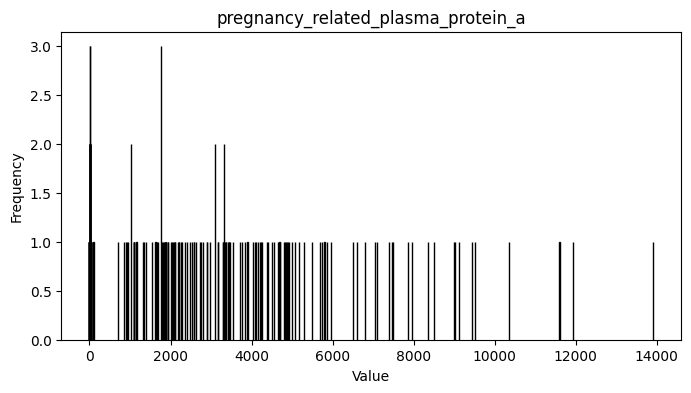

In [195]:
col = "pregnancy_related_plasma_protein_a"

# Plot column values distribution
plot_histogram(df, col, 1)

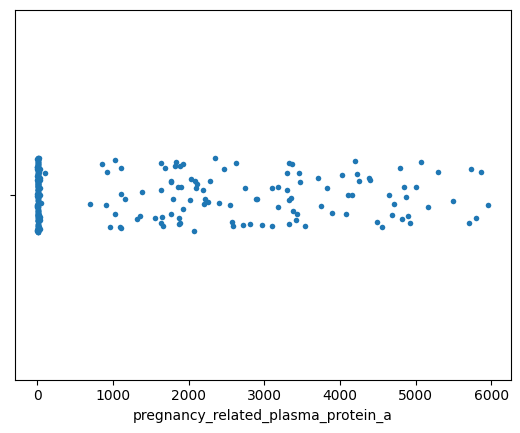

In [196]:
# Remove outliers in column
filtered_vals, df_temp = remove_outliers(df, col, 1.5)

# Plot after removing outliers to detect the threshold
plot_dots(df_temp, col)

Lower Bound: 99.27
Upper Bound: 696.0
Suggested Threshold: 397.635


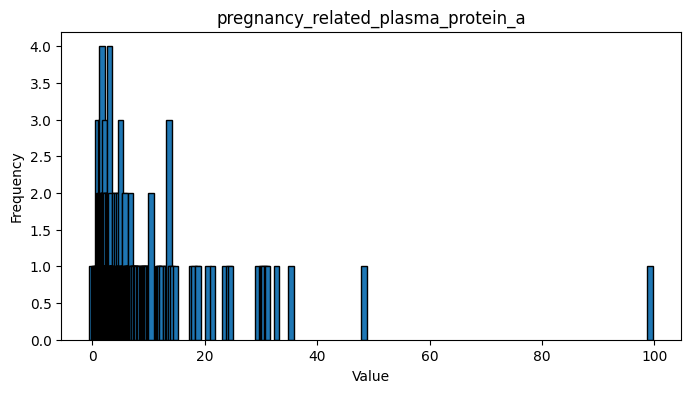

In [197]:
threshold = find_threshold(filtered_vals)

# Convert to miu/ml (value / 1000)
mask_ml = df[col] > threshold
df.loc[mask_ml, col] = df.loc[mask_ml, col] / 1000

# Plot after unit change -> THERE IS AGAIN SOME OUTLIERS!!
plot_histogram(df, col, 1)

## free_beta_hcg

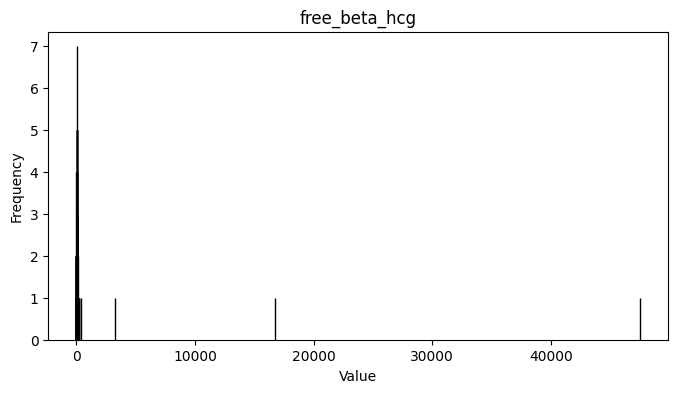

In [198]:
col = "free_beta_hcg"   # miu/ml = iu/l

# Plot column values distribution
plot_histogram(df, col, 1)

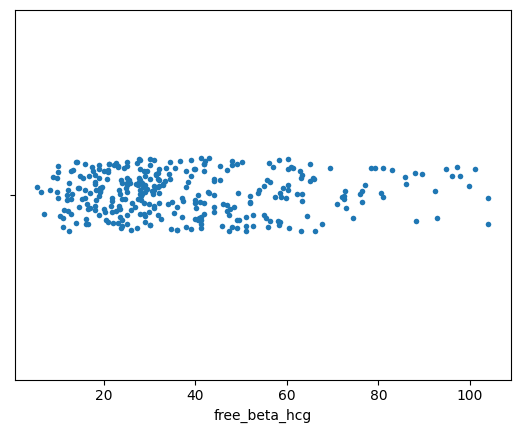

In [199]:
# Remove outliers in column
filtered_vals, df_temp = remove_outliers(df, col, 1.5)

# Plot after removing outliers to detect the threshold
plot_dots(df_temp, col)

Here is only some outliers, and others seems to be in the same unit.

## alpha_fetoprotein

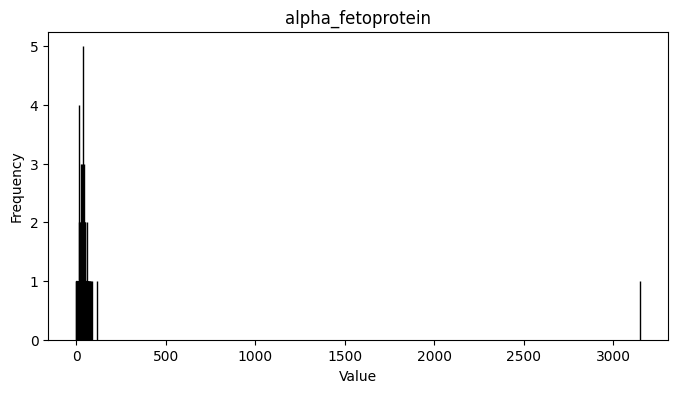

In [200]:
col = "alpha_fetoprotein"   # ng/ml

# Plot column values distribution
plot_histogram(df, col, 0.5)

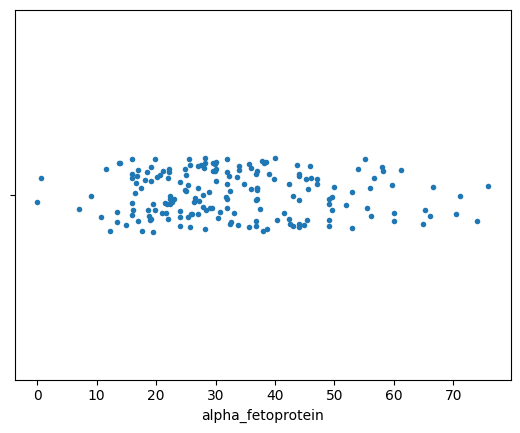

In [201]:
# Remove outliers in column
filtered_vals, df_temp = remove_outliers(df, col, 1.5)

# Plot after removing outliers to detect the threshold
plot_dots(df_temp, col)

In [202]:
# threshold = 2500  # no need to do any calculations to find that

# # Convert iu/ml to miu/ml by (value * 1000)
# mask_ml = df[col] < threshold
# df.loc[mask_ml, col] = df.loc[mask_ml, col] * 1000

# # Plot after unit change -> THERE IS AGAIN SOME OUTLIERS!!
# plot_histogram(df, col, 1)

## estriol

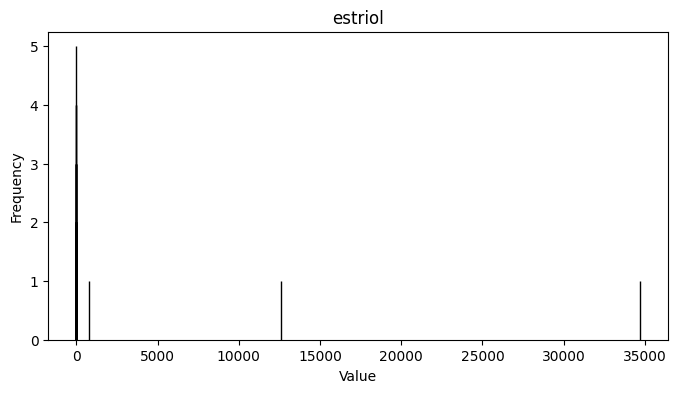

In [203]:
col = "estriol"   # ng/ml

# Plot column values distribution
plot_histogram(df, col, 0.1)

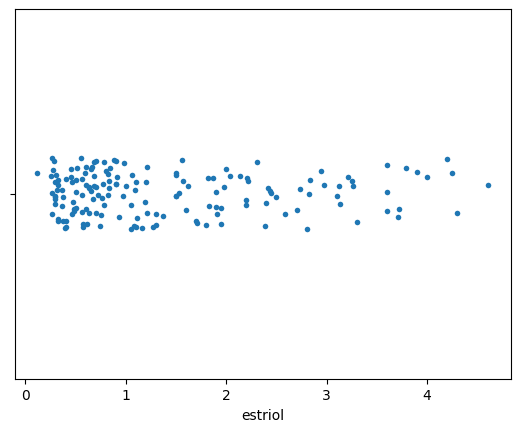

In [204]:
# Remove outliers in column
filtered_vals, df_temp = remove_outliers(df, col, 1.5)

# Plot after removing outliers to detect the threshold
plot_dots(df_temp, col)

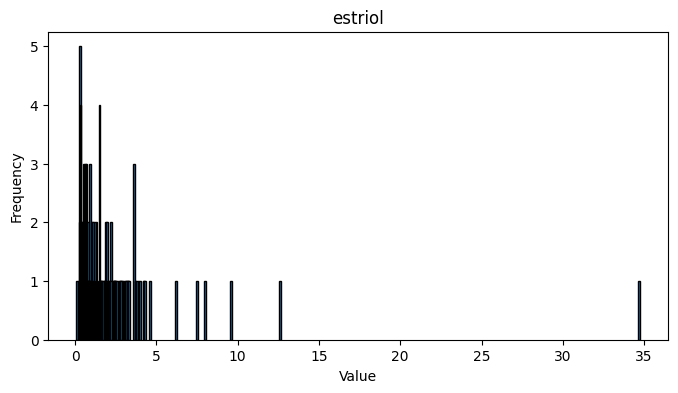

In [205]:
threshold = 100  # no need to do any calculations to find that

# Convert iu/ml to miu/ml by (value / 1000)
mask_ml = df[col] > threshold
df.loc[mask_ml, col] = df.loc[mask_ml, col] / 1000

# Plot after unit change -> THERE IS AGAIN SOME OUTLIERS!!
plot_histogram(df, col, 0.1)

## bhcg_total

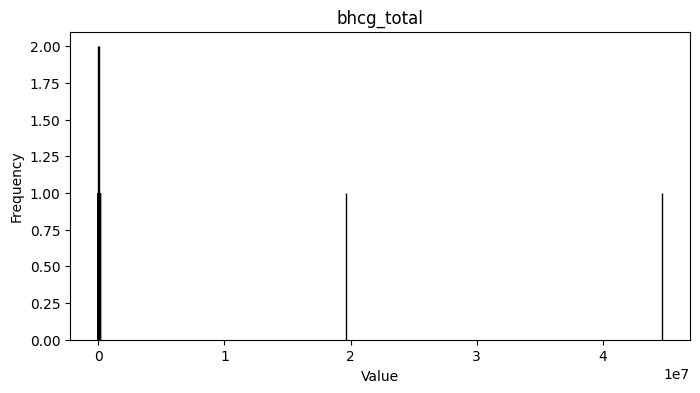

In [206]:
col = "bhcg_total"  # miu/ml

# Plot column values distribution
plot_histogram(df, col, 1)

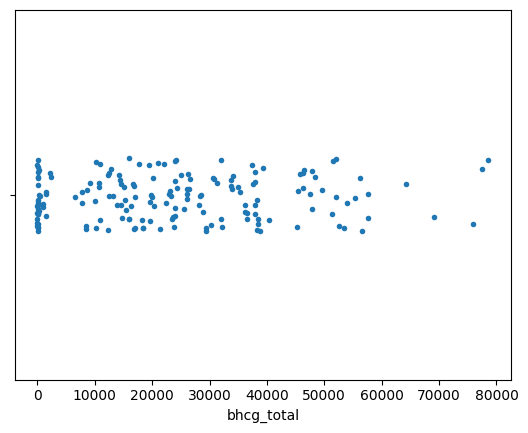

In [207]:
# Remove outliers in column
filtered_vals, df_temp = remove_outliers(df, col, 1.5)

# Plot after removing outliers to detect the threshold
plot_dots(df_temp, col)

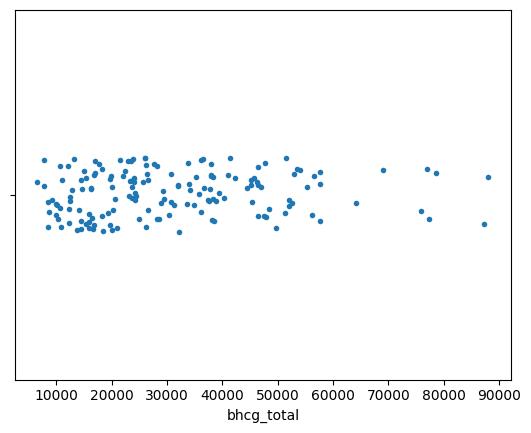

In [208]:
threshold = 5000

# Convert iu/ml to miu/ml by (value * 1000)
mask_ml = df[col] < threshold
df.loc[mask_ml, col] = df.loc[mask_ml, col] * 1000

# Plot after unit change -> THERE IS AGAIN SOME OUTLIERS!!
# Remove outliers in column
filtered_vals, df_temp = remove_outliers(df, col, 1.5)

# Plot after removing outliers to detect the threshold
plot_dots(df_temp, col)

In [209]:
# import matplotlib.pyplot as plt

# df[col].hist(bins=50)
# plt.xlabel('Value')
# plt.ylabel('Frequency')
# plt.title('Distribution')
# plt.show()

# Handling Nan values

## Columns (A-Z)

In [210]:
print(df[df["id"].isna()]["index"])

Series([], Name: index, dtype: int64)


In [211]:
print("-- Check age")
df = numerics_fill_na(df, "moth_age")

print("\n-- Check weight")
df = numerics_fill_na(df, "moth_weight")

print("\n-- Check Height")
df = numerics_fill_na(df, "moth_height")

-- Check age
Number of nan values in moth_age: 1
Median in moth_age = 29.0
Number of nan values in moth_age after handling: 0

-- Check weight
Number of nan values in moth_weight: 746
Median in moth_weight = 72.0
Number of nan values in moth_weight after handling: 0

-- Check Height
Number of nan values in moth_height: 727
Median in moth_height = 160.0
Number of nan values in moth_height after handling: 0


In [212]:
print("-- Check Parents Relationship")
df = categoricals_fill_na(df, "parent_relat")

print("\n-- Check Race")
df = categoricals_fill_na(df, "race")

-- Check Parents Relationship
Number of nan values in parent_relat: 279
Mode in parent_relat = 0.0
Number of nan values in parent_relat after handling: 0

-- Check Race
Number of nan values in race: 128
Mode in race = 1.0
Number of nan values in race after handling: 0


In [213]:
print("-- Number of Pregnancies")
df = numerics_fill_na(df, "num_preg")

print("\n-- Number of Births")
df = numerics_fill_na(df, "num_births")

print("\n-- Number of Stillborns")
df = numerics_fill_na(df, "num_stillborns")

print("\n-- Number of Maternal Deaths")
df = numerics_fill_na(df, "num_maternal_deaths")

print("\n-- Number of Abortions")
df = numerics_fill_na(df, "cnt_abortions")

-- Number of Pregnancies
Number of nan values in num_preg: 46
Median in num_preg = 2.0
Number of nan values in num_preg after handling: 0

-- Number of Births
Number of nan values in num_births: 44
Median in num_births = 1.0
Number of nan values in num_births after handling: 0

-- Number of Stillborns
Number of nan values in num_stillborns: 50
Median in num_stillborns = 0.0
Number of nan values in num_stillborns after handling: 0

-- Number of Maternal Deaths
Number of nan values in num_maternal_deaths: 49
Median in num_maternal_deaths = 0.0
Number of nan values in num_maternal_deaths after handling: 0

-- Number of Abortions
Number of nan values in cnt_abortions: 48
Median in cnt_abortions = 0.0
Number of nan values in cnt_abortions after handling: 0


In [214]:
print("-- Check Privous Prem Birth")
df = categoricals_fill_na(df, "prev_prem_birth")

-- Check Privous Prem Birth
Number of nan values in prev_prem_birth: 14
Mode in prev_prem_birth = 0.0
Number of nan values in prev_prem_birth after handling: 0


In [215]:
print("-- Check Previous PPROM")
df = categoricals_fill_na(df, "prev_pprom")

print("\n-- Check Previous Heart Disease")
df = categoricals_fill_na(df, "prev_heart_disease")

-- Check Previous PPROM
Number of nan values in prev_pprom: 12
Mode in prev_pprom = 0.0
Number of nan values in prev_pprom after handling: 0

-- Check Previous Heart Disease
Number of nan values in prev_heart_disease: 27
Mode in prev_heart_disease = 0.0
Number of nan values in prev_heart_disease after handling: 0


In [216]:
from sklearn.preprocessing import OneHotEncoder

print("-- Check Previous Diabetes")
df = categoricals_fill_na(df, "prev_diabetes")

# one hot encoding for multi categorical column
ohe = OneHotEncoder(sparse_output=False, drop=None)
encoded = ohe.fit_transform(df[["prev_diabetes"]])
original_cols = ohe.get_feature_names_out(["prev_diabetes"])

df_ohe = pd.DataFrame(encoded, columns=original_cols, index=df.index)

rename_map = {
    original_cols[0]: "no_diabetes",
    original_cols[1]: "prev_diabetes",
    original_cols[2]: "pregnancy_diabetes"
}
df_ohe = df_ohe.rename(columns=rename_map)

df = df.drop(columns=["prev_diabetes"])

df = pd.concat([df, df_ohe], axis=1)

df.head()

-- Check Previous Diabetes
Number of nan values in prev_diabetes: 26
Mode in prev_diabetes = 0.0
Number of nan values in prev_diabetes after handling: 0


,index,id,moth_age,moth_weight,moth_height,parent_relat,race,num_preg,num_births,num_stillborns,...,kidney_eval,fetal_bladder_eval,placenta_vessels_eval,fetal_limbs_eval,nb_attachment_eval,spinal_processes_eval,preeclampsia,no_diabetes,prev_diabetes,pregnancy_diabetes
0,1,213997.0,36.0,72.0,160.0,1.0,0.0,6.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0
1,2,1279574.0,39.0,72.0,160.0,0.0,0.0,4.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0
2,3,2319555.0,21.0,72.0,160.0,0.0,1.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0
3,4,2518474.0,29.0,66.0,161.0,1.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0
4,5,2528353.0,26.0,69.0,150.0,0.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1.0,0.0,0.0


In [217]:
print("-- Check Previous Minor Thalasemy")
df = categoricals_fill_na(df, "prev_minor_thal")

-- Check Previous Minor Thalasemy
Number of nan values in prev_minor_thal: 16
Mode in prev_minor_thal = 0.0
Number of nan values in prev_minor_thal after handling: 0


In [218]:
print("-- Check Blood Nitrogen Level")   # checked with normal value
df = numerics_fill_na(df, "blood_nitrogen_level")

print("\n-- Level of Urine Creatinine")  # checked with normal value (NOT MATCHED!)
df = numerics_fill_na(df, "urine_creatinine_level")

-- Check Blood Nitrogen Level
Number of nan values in blood_nitrogen_level: 924
Median in blood_nitrogen_level = 8.88
Number of nan values in blood_nitrogen_level after handling: 0

-- Level of Urine Creatinine
Number of nan values in urine_creatinine_level: 691
Median in urine_creatinine_level = 0.7
Number of nan values in urine_creatinine_level after handling: 0


In [219]:
print("-- Hbs-Ag")
df = categoricals_fill_na(df, "hbs_ag")

print("\n-- Urine Culture")
df = categoricals_fill_na(df, "urine_culture")

print("\n-- Syphilis Screening VDRL")
df = categoricals_fill_na(df, "syphilis_screening_vdrl")

-- Hbs-Ag
Number of nan values in hbs_ag: 306
Mode in hbs_ag = 0.0
Number of nan values in hbs_ag after handling: 0

-- Urine Culture
Number of nan values in urine_culture: 213
Mode in urine_culture = 0.0
Number of nan values in urine_culture after handling: 0

-- Syphilis Screening VDRL
Number of nan values in syphilis_screening_vdrl: 396
Mode in syphilis_screening_vdrl = 0.0
Number of nan values in syphilis_screening_vdrl after handling: 0


In [220]:
print("-- Fasting Blodd Glucose Value")     # checked with normal value
df = numerics_fill_na(df, "fasting_blood_glucose")

print("\n-- Thyroid Stimulating Hormone")   # checked with normal value
df = numerics_fill_na(df, "thyroid_stimulating_hormone")

-- Fasting Blodd Glucose Value
Number of nan values in fasting_blood_glucose: 197
Median in fasting_blood_glucose = 82.0
Number of nan values in fasting_blood_glucose after handling: 0

-- Thyroid Stimulating Hormone
Number of nan values in thyroid_stimulating_hormone: 272
Median in thyroid_stimulating_hormone = 1.8
Number of nan values in thyroid_stimulating_hormone after handling: 0


In [221]:
print("-- Glucose Tolerance Test Results")  # checked with normal value
df = categoricals_fill_na(df, "glucose_tolerance_test")

-- Glucose Tolerance Test Results
Number of nan values in glucose_tolerance_test: 498
Mode in glucose_tolerance_test = 0.0
Number of nan values in glucose_tolerance_test after handling: 0


In [222]:
print("-- Result of Nuchal Translucency Test")   # checked with normal value
df = numerics_fill_na(df, "nuchal_translucency_test")

-- Result of Nuchal Translucency Test
Number of nan values in nuchal_translucency_test: 1015
Median in nuchal_translucency_test = 1.5
Number of nan values in nuchal_translucency_test after handling: 0


## Columns (AA-AZ)

In [223]:
print("-- Result of Plasma Protein A")   # (need MoM)
df = numerics_fill_na(df, "pregnancy_related_plasma_protein_a")

print("\n-- Free Beta-hCG")    # (need MoM)
df = numerics_fill_na(df, "free_beta_hcg")

print("\n-- Alpha Fetoprotein")   # (need MoM)
df = numerics_fill_na(df, "alpha_fetoprotein")

print("\n-- Esteriol")    # (need MoM)
df = numerics_fill_na(df, "estriol")

print("\n-- Inhibin-A")   # (need MoM)
df = numerics_fill_na(df, "inhibin_a")

print("\n-- BHCG Total")   # (need MoM)
df = numerics_fill_na(df, "bhcg_total")

-- Result of Plasma Protein A
Number of nan values in pregnancy_related_plasma_protein_a: 929
Median in pregnancy_related_plasma_protein_a = 3.2085
Number of nan values in pregnancy_related_plasma_protein_a after handling: 0

-- Free Beta-hCG
Number of nan values in free_beta_hcg: 904
Median in free_beta_hcg = 34.0
Number of nan values in free_beta_hcg after handling: 0

-- Alpha Fetoprotein
Number of nan values in alpha_fetoprotein: 1063
Median in alpha_fetoprotein = 30.5737
Number of nan values in alpha_fetoprotein after handling: 0

-- Esteriol
Number of nan values in estriol: 1082
Median in estriol = 1.05
Number of nan values in estriol after handling: 0

-- Inhibin-A
Number of nan values in inhibin_a: 1082
Median in inhibin_a = 223.8
Number of nan values in inhibin_a after handling: 0

-- BHCG Total
Number of nan values in bhcg_total: 1073
Median in bhcg_total = 30687.0
Number of nan values in bhcg_total after handling: 0


In [224]:
print("-- Temporal Bone Diameter")   # PREG. WEEK IS IMPORTANT!
df = numerics_fill_na(df, "temporal_bone_diameter")

print("\n-- Head Circumference")    # PREG. WEEK IS IMPORTANT!
df = numerics_fill_na(df, "fetal_head_circumference")

print("\n-- Abdominal Circumference")  # PREG. WEEK IS IMPORTANT!
df = numerics_fill_na(df, "fetal_abdominal_circumference")

print("\n-- Femur Length")  # PREG. WEEK IS IMPORTANT!
df = numerics_fill_na(df, "fetal_femur_length")

print("\n-- Weight Estimation")   # PREG. WEEK IS IMPORTANT!
df = numerics_fill_na(df, "fetal_weight_estimation")

print("\n-- Cervical Length")  
df = numerics_fill_na(df, "cervical_length")

print("\n-- Nuchal Skin Fold")   # NOT EXACTLY IN NORMAL RANGE!
df = numerics_fill_na(df, "nuchal_skin_fold")

-- Temporal Bone Diameter
Number of nan values in temporal_bone_diameter: 288
Median in temporal_bone_diameter = 43.0
Number of nan values in temporal_bone_diameter after handling: 0

-- Head Circumference
Number of nan values in fetal_head_circumference: 569
Median in fetal_head_circumference = 158.0
Number of nan values in fetal_head_circumference after handling: 0

-- Abdominal Circumference
Number of nan values in fetal_abdominal_circumference: 558
Median in fetal_abdominal_circumference = 135.0
Number of nan values in fetal_abdominal_circumference after handling: 0

-- Femur Length
Number of nan values in fetal_femur_length: 445
Median in fetal_femur_length = 28.0
Number of nan values in fetal_femur_length after handling: 0

-- Weight Estimation
Number of nan values in fetal_weight_estimation: 67
Median in fetal_weight_estimation = 266.0
Number of nan values in fetal_weight_estimation after handling: 0

-- Cervical Length
Number of nan values in cervical_length: 576
Median in cerv

In [225]:
print("-- Ventriculomegaly")
df = categoricals_fill_na(df, "ventriculomegaly")

print("\n-- Hyper Echo Intestines")
df = categoricals_fill_na(df, "hyper_echo_intestines")

print("\n-- Intra Cardiac Exho Focus")
df = categoricals_fill_na(df, "intra_cardiac_echo_focus")

print("\n-- Choroid Plexus Cyst")
df = categoricals_fill_na(df, "choroid_plexus_cyst")

print("\n-- Pyelectasis")
df = categoricals_fill_na(df, "pyelectasis")

-- Ventriculomegaly
Number of nan values in ventriculomegaly: 63
Mode in ventriculomegaly = 0.0
Number of nan values in ventriculomegaly after handling: 0

-- Hyper Echo Intestines
Number of nan values in hyper_echo_intestines: 65
Mode in hyper_echo_intestines = 0.0
Number of nan values in hyper_echo_intestines after handling: 0

-- Intra Cardiac Exho Focus
Number of nan values in intra_cardiac_echo_focus: 65
Mode in intra_cardiac_echo_focus = 0.0
Number of nan values in intra_cardiac_echo_focus after handling: 0

-- Choroid Plexus Cyst
Number of nan values in choroid_plexus_cyst: 65
Mode in choroid_plexus_cyst = 0.0
Number of nan values in choroid_plexus_cyst after handling: 0

-- Pyelectasis
Number of nan values in pyelectasis: 64
Mode in pyelectasis = 0.0
Number of nan values in pyelectasis after handling: 0


In [226]:
print("-- Apgar")   
df = numerics_fill_na(df, "apgar")

-- Apgar
Number of nan values in apgar: 203
Median in apgar = 10.0
Number of nan values in apgar after handling: 0


In [227]:
print("-- Skull Structure")
df = categoricals_fill_na(df, "skull_structure_anomaly_scan")

-- Skull Structure
Number of nan values in skull_structure_anomaly_scan: 65
Mode in skull_structure_anomaly_scan = 0.0
Number of nan values in skull_structure_anomaly_scan after handling: 0


In [228]:
print("-- Lateral Ventricles Size") 
df = numerics_fill_na(df, "lateral_ventricles_size_anomaly_scan")

-- Lateral Ventricles Size
Number of nan values in lateral_ventricles_size_anomaly_scan: 746
Median in lateral_ventricles_size_anomaly_scan = 6.95
Number of nan values in lateral_ventricles_size_anomaly_scan after handling: 0


In [229]:
print("-- Choroid Plexus")
df = categoricals_fill_na(df, "choroid_plexus_anomaly_scan")

print("\n-- Cavum Septum Pellucidum")
df = categoricals_fill_na(df, "cavum_septum_pellucidum_anomaly_scan")

print("\n-- Falx Cerebri Midline")
df = categoricals_fill_na(df, "falx_cerebri_midline_anomaly_scan")

-- Choroid Plexus
Number of nan values in choroid_plexus_anomaly_scan: 62
Mode in choroid_plexus_anomaly_scan = 0.0
Number of nan values in choroid_plexus_anomaly_scan after handling: 0

-- Cavum Septum Pellucidum
Number of nan values in cavum_septum_pellucidum_anomaly_scan: 66
Mode in cavum_septum_pellucidum_anomaly_scan = 0.0
Number of nan values in cavum_septum_pellucidum_anomaly_scan after handling: 0

-- Falx Cerebri Midline
Number of nan values in falx_cerebri_midline_anomaly_scan: 69
Mode in falx_cerebri_midline_anomaly_scan = 0.0
Number of nan values in falx_cerebri_midline_anomaly_scan after handling: 0


In [230]:
print("-- Evaluation of Brain Size")   # PREG. WEEK IS IMPORTANT!
df = numerics_fill_na(df, "brain_size_eval")

print("\n-- Evaluation of Cisterna Magna")
df = numerics_fill_na(df, "cisterna_magna_eval")

-- Evaluation of Brain Size
Number of nan values in brain_size_eval: 677
Median in brain_size_eval = 18.7
Number of nan values in brain_size_eval after handling: 0

-- Evaluation of Cisterna Magna
Number of nan values in cisterna_magna_eval: 676
Median in cisterna_magna_eval = 4.4
Number of nan values in cisterna_magna_eval after handling: 0


## Columns (BA-BQ)

In [231]:
print("-- Evaluation of Lips and Nose")  # checked with normal value (PREG. WEEK IS IMPORTANT!)
df = numerics_fill_na(df, "lips_nose_eval")

-- Evaluation of Lips and Nose
Number of nan values in lips_nose_eval: 618
Median in lips_nose_eval = 5.7
Number of nan values in lips_nose_eval after handling: 0


In [232]:
print("-- Evaluation of Orbital Cavity")
df = categoricals_fill_na(df, "orbital_cavity_eval")

print("\n-- Evaluation of Upper Lip")
df = categoricals_fill_na(df, "upper_lip_eval")

-- Evaluation of Orbital Cavity
Number of nan values in orbital_cavity_eval: 57
Mode in orbital_cavity_eval = 0.0
Number of nan values in orbital_cavity_eval after handling: 0

-- Evaluation of Upper Lip
Number of nan values in upper_lip_eval: 56
Mode in upper_lip_eval = 0.0
Number of nan values in upper_lip_eval after handling: 0


In [233]:
print("-- Evaluation of Heart Rate")    # checked with normal value
df = numerics_fill_na(df, "fetal_heart_rate_eval")

-- Evaluation of Heart Rate
Number of nan values in fetal_heart_rate_eval: 161
Median in fetal_heart_rate_eval = 147.0
Number of nan values in fetal_heart_rate_eval after handling: 0


In [234]:
print("-- Evaluation of Heart")
df = categoricals_fill_na(df, "fetal_heart_eval")

print("\n-- Evaluation of Heart Chambers")
df = categoricals_fill_na(df, "fetal_heart_chambers_eval")

print("\n-- Evaluation of Lungs")
df = categoricals_fill_na(df, "lungs_eval")

print("\n-- Evaluation of Diaphragm")
df = categoricals_fill_na(df, "diaphragm_eval")

print("\n-- Evaluation of abd wall")
df = categoricals_fill_na(df, "abd_wall_nb_eval")

print("\n-- Evaluation of Stomach")
df = categoricals_fill_na(df, "stomach_eval")

-- Evaluation of Heart
Number of nan values in fetal_heart_eval: 50
Mode in fetal_heart_eval = 0.0
Number of nan values in fetal_heart_eval after handling: 0

-- Evaluation of Heart Chambers
Number of nan values in fetal_heart_chambers_eval: 49
Mode in fetal_heart_chambers_eval = 0.0
Number of nan values in fetal_heart_chambers_eval after handling: 0

-- Evaluation of Lungs
Number of nan values in lungs_eval: 53
Mode in lungs_eval = 0.0
Number of nan values in lungs_eval after handling: 0

-- Evaluation of Diaphragm
Number of nan values in diaphragm_eval: 50
Mode in diaphragm_eval = 0.0
Number of nan values in diaphragm_eval after handling: 0

-- Evaluation of abd wall
Number of nan values in abd_wall_nb_eval: 51
Mode in abd_wall_nb_eval = 0.0
Number of nan values in abd_wall_nb_eval after handling: 0

-- Evaluation of Stomach
Number of nan values in stomach_eval: 50
Mode in stomach_eval = 0.0
Number of nan values in stomach_eval after handling: 0


In [235]:
print("-- Evaluation of Kidney")
df = categoricals_fill_na(df, "kidney_eval")

print("\n-- Evaluation of Bladder")
df = categoricals_fill_na(df, "fetal_bladder_eval")

print("\n-- Evaluation of Placenta Vessels")
df = categoricals_fill_na(df, "placenta_vessels_eval")

print("\n-- Evaluation of Limbs")
df = categoricals_fill_na(df, "fetal_limbs_eval")

print("\n-- Evaluation of nb Attachment")
df = categoricals_fill_na(df, "nb_attachment_eval")

print("\n-- Evaluation of Spinal Processes")
df = categoricals_fill_na(df, "spinal_processes_eval")

print("\n-- Preeclampsia")
df = categoricals_fill_na(df, "preeclampsia")

-- Evaluation of Kidney
Number of nan values in kidney_eval: 49
Mode in kidney_eval = 0.0
Number of nan values in kidney_eval after handling: 0

-- Evaluation of Bladder
Number of nan values in fetal_bladder_eval: 49
Mode in fetal_bladder_eval = 0.0
Number of nan values in fetal_bladder_eval after handling: 0

-- Evaluation of Placenta Vessels
Number of nan values in placenta_vessels_eval: 51
Mode in placenta_vessels_eval = 0.0
Number of nan values in placenta_vessels_eval after handling: 0

-- Evaluation of Limbs
Number of nan values in fetal_limbs_eval: 54
Mode in fetal_limbs_eval = 0.0
Number of nan values in fetal_limbs_eval after handling: 0

-- Evaluation of nb Attachment
Number of nan values in nb_attachment_eval: 52
Mode in nb_attachment_eval = 0.0
Number of nan values in nb_attachment_eval after handling: 0

-- Evaluation of Spinal Processes
Number of nan values in spinal_processes_eval: 73
Mode in spinal_processes_eval = 0.0
Number of nan values in spinal_processes_eval after

# Handling Outliers (Numerics)

## Columns (A-Z)

In [236]:
print("-- Check age")
print(df["moth_age"].describe())

-- Check age
count    1251.000000
mean       29.013589
std         6.196726
min        13.000000
25%        24.000000
50%        29.000000
75%        33.000000
max        55.000000
Name: moth_age, dtype: float64


In [237]:
print("-- Check weight")
print(df["moth_weight"].describe())

df['moth_weight'].value_counts().sort_index()

-- Check weight
count    1251.000000
mean       72.936611
std        10.009122
min        43.000000
25%        72.000000
50%        72.000000
75%        72.000000
max       168.000000
Name: moth_weight, dtype: float64


moth_weight
43.0     1
45.0     3
47.0     1
49.0     2
49.5     1
        ..
128.0    1
130.0    1
153.0    1
158.0    1
168.0    1
Name: count, Length: 99, dtype: int64

In [238]:
# check big numbers for weight (it is true!)
df[df["moth_weight"] == 153]["moth_height"]

100    160.0
Name: moth_height, dtype: float64

In [239]:
print("-- Check Height")
print(df["moth_height"].describe())

df['moth_height'].value_counts().sort_index()

-- Check Height
count    1251.000000
mean      154.833813
std        21.831051
min        41.000000
25%       160.000000
50%       160.000000
75%       160.000000
max       212.000000
Name: moth_height, dtype: float64


moth_height
41.0     1
43.0     1
45.0     1
48.3     1
50.0     1
        ..
176.0    2
177.0    1
178.0    1
179.0    1
212.0    1
Name: count, Length: 87, dtype: int64

In [240]:
# heights less than 100 should added to 100
mask = df['moth_height'] < 100
df.loc[mask, 'moth_height'] = df.loc[mask, 'moth_height'] + 100

# check the min and max of height after process
print(df["moth_height"].describe())

count    1251.000000
mean      160.669145
std         5.726562
min       110.000000
25%       160.000000
50%       160.000000
75%       160.000000
max       212.000000
Name: moth_height, dtype: float64


In [241]:
print("-- Number of Pregnancies")
print(df['num_preg'].value_counts().sort_index())

print("\n-- Number of Births")
print(df['num_births'].value_counts().sort_index())

print("\n-- Number of Stillborns")
print(df['num_stillborns'].value_counts().sort_index())

print("\n-- Number of Maternal Deaths")
print(df['num_maternal_deaths'].value_counts().sort_index())

print("\n-- Number of Abortions")
print(df['cnt_abortions'].value_counts().sort_index())

-- Number of Pregnancies
num_preg
1.0     299
2.0     413
3.0     291
4.0     127
5.0      76
6.0      25
7.0       9
8.0      10
10.0      1
Name: count, dtype: int64

-- Number of Births
num_births
0.0    200
1.0    450
2.0    338
3.0    169
4.0     56
5.0     24
6.0     11
7.0      2
9.0      1
Name: count, dtype: int64

-- Number of Stillborns
num_stillborns
0.0    1237
1.0      11
2.0       1
3.0       1
4.0       1
Name: count, dtype: int64

-- Number of Maternal Deaths
num_maternal_deaths
0.0    1233
1.0      13
2.0       5
Name: count, dtype: int64

-- Number of Abortions
cnt_abortions
0.0    1009
1.0     180
2.0      44
3.0      13
4.0       4
5.0       1
Name: count, dtype: int64


In [242]:
print("-- Check Blood Nitrogen Level")
col = "blood_nitrogen_level"

# inspect current values
print(df[col].value_counts().sort_index())

# Normal range for pregnancy
normal_min = 7
normal_max = 14

# Outlier boundaries (medical)
outlier_min = 3
outlier_max = 25

# mask outliers
outlier_mask  = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# refine outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max

# --- masks ---
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask) 

# convert to categories
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# describe
print(df[col].describe())

-- Check Blood Nitrogen Level
blood_nitrogen_level
3.60     1
4.67     1
4.70     2
4.80     2
5.00     9
        ..
19.00    2
20.00    3
21.00    5
22.00    3
23.00    2
Name: count, Length: 93, dtype: int64
Outliers:
Series([], Name: blood_nitrogen_level, dtype: float64)
count    1251.000000
mean        9.059592
std         1.909288
min         3.600000
25%         8.880000
50%         8.880000
75%         8.880000
max        23.000000
Name: blood_nitrogen_level, dtype: float64


In [243]:
## WRONG RANGES !!!!!
print("-- Level of Urine Creatinine") 
col = "urine_creatinine_level"

# check existing unique values
print(df[col].value_counts().sort_index())

# defining normal range
normal_min = 20   # mg/dl
normal_max = 275  

# defining outlier range
outlier_min = 5
outlier_max = 500

# creating mask for outliers
outlier_mask  = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# refine outliers 
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max

# creating masks
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # Numerical to Categorical
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# check range of data after process 
print(df[col].describe())

-- Level of Urine Creatinine
urine_creatinine_level
0.30       1
0.33       1
0.37       1
0.40       6
0.41       1
          ..
925.00     1
1103.00    1
1178.00    1
1187.00    1
1377.00    1
Name: count, Length: 74, dtype: int64
Outliers:
0       0.7
1       0.7
2       0.7
3       0.7
4       0.7
       ... 
1789    0.7
1794    0.7
1795    0.7
1801    0.8
1809    0.6
Name: urine_creatinine_level, Length: 1247, dtype: float64
count    1251.000000
mean        9.542894
std        46.178563
min         5.000000
25%         5.000000
50%         5.000000
75%         5.000000
max       500.000000
Name: urine_creatinine_level, dtype: float64


In [244]:
print("-- Fasting Blodd Glucose Value") 
col = "fasting_blood_glucose"

# check existing unique values
print(df[col].value_counts().sort_index())

# defining normal range (ADA / IADPSG)
normal_min = 70  # mg/dl
normal_max = 92

# defining outlier range (suspicious / non-physiologic)
outlier_min = 40
outlier_max = 250

# creating mask for outliers
outlier_mask  = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# refine outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max

# creating masks
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # Numerical to Categorical
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# check range of data after process 
print(df[col].describe())

-- Fasting Blodd Glucose Value
fasting_blood_glucose
51.0     1
53.0     1
54.0     1
55.0     1
58.0     2
        ..
142.0    1
155.0    1
170.0    1
188.0    1
232.0    1
Name: count, Length: 75, dtype: int64
Outliers:
Series([], Name: fasting_blood_glucose, dtype: float64)
count    1251.000000
mean       82.991207
std        11.215896
min        51.000000
25%        77.000000
50%        82.000000
75%        87.000000
max       232.000000
Name: fasting_blood_glucose, dtype: float64


In [245]:
print("-- Thyroid Stimulating Hormone")  
col = "thyroid_stimulating_hormone"

# check existing unique values
print(df[col].value_counts().sort_index())

# defining normal range (pregnancy guideline)
normal_min = 0.1  # mIU/L
normal_max = 4.0

# defining outlier range
outlier_min = 0.001
outlier_max = 50

# creating mask for outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# refine outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max

# Do this if needed!
# df[col] = np.log1p(df[col])

# creating masks
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_high = (df[col] > normal_max)  # Hypothyroid (high)
abnormal_low  = (df[col] < normal_min)  # Hyperthyroid (low)
# abnormal_mask = (~normal_mask)

# # Numerical to Categorical
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_low, col] = 1
# df.loc[abnormal_high, col] = 2

# check range of data after process
print(df[col].describe())

-- Thyroid Stimulating Hormone
thyroid_stimulating_hormone
0.004      1
0.005      1
0.010      1
0.020      2
0.050      1
          ..
12.800     1
13.300     1
18.860     1
37.000     1
125.000    1
Name: count, Length: 284, dtype: int64
Outliers:
35    125.0
Name: thyroid_stimulating_hormone, dtype: float64
count    1251.000000
mean        2.169247
std         2.280390
min         0.004000
25%         1.290000
50%         1.800000
75%         2.500000
max        50.000000
Name: thyroid_stimulating_hormone, dtype: float64


In [246]:
print("-- Result of Nuchal Translucency Test")  
col = "nuchal_translucency_test"

# check existing unique values
print(df[col].value_counts().sort_index())

# physiological normal range
normal_min = 0.9  # mm
normal_max = 2.8

# outlier detection thresholds (technical impossibility)
outlier_min = 0.3  # less than 0.8 this value is a technical error
outlier_max = 6.0

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # turn into 0/1 (optional)
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Result of Nuchal Translucency Test
nuchal_translucency_test
0.66    1
0.70    1
0.80    1
0.86    1
0.90    4
       ..
2.40    2
2.50    1
2.60    1
3.40    1
4.65    1
Name: count, Length: 74, dtype: int64
Outliers:
Series([], Name: nuchal_translucency_test, dtype: float64)
count    1251.000000
mean        1.503869
std         0.178425
min         0.660000
25%         1.500000
50%         1.500000
75%         1.500000
max         4.650000
Name: nuchal_translucency_test, dtype: float64


## Columns (AA-AZ)

In [247]:
print("-- Result of Plasma Protein A")
col = "pregnancy_related_plasma_protein_a"

# check existing unique values
print(df[col].value_counts().sort_index())

# physiological / typical normal-ish range (for raw mIU/mL, first trimester)
normal_min = 1.0   # mIU/mL
normal_max = 10.0  # mIU/mL

# outlier detection thresholds (technical / unit errors)
outlier_min = 0.01   # values below this are considered technical error
outlier_max = 50.0   # values above this likely unit / entry error

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # turn into 0/1 (optional)
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Result of Plasma Protein A
pregnancy_related_plasma_protein_a
0.00293     1
0.30000     1
0.49000     1
0.69600     1
0.85500     1
           ..
31.20000    1
32.80000    1
35.40000    1
48.30000    1
99.27000    1
Name: count, Length: 281, dtype: int64
Outliers:
481     0.00293
930    99.27000
Name: pregnancy_related_plasma_protein_a, dtype: float64
count    1251.000000
mean        3.791988
std         3.586707
min         0.010000
25%         3.208500
50%         3.208500
75%         3.208500
max        50.000000
Name: pregnancy_related_plasma_protein_a, dtype: float64


In [248]:
print("-- Free Beta-hCG")  
col = "free_beta_hcg"

# check existing unique values
print(df[col].value_counts().sort_index())

# physiological typical range (first trimester, raw mIU/mL)
normal_min = 10.0
normal_max = 200.0

# outlier detection thresholds (likely unit or entry errors)
outlier_min = 1.0
outlier_max = 1000.0

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = df[col]*1000
df.loc[df[col] > outlier_max, col] = df[col]/1000

# Do it if needed!
# df[col] = np.log1p(df[col])

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_high = (df[col] > normal_max) 
abnormal_low  = (df[col] < normal_min)  
# abnormal_mask = (~normal_mask)

# # turn to binary (optional)
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_low, col] = 1
# df.loc[abnormal_high, col] = 2

# summary
print(df[col].describe())

-- Free Beta-hCG
free_beta_hcg
5.50        1
6.37        1
7.00        1
8.19        1
9.00        1
           ..
218.00      1
413.00      1
3285.00     1
16757.00    1
47500.00    1
Name: count, Length: 263, dtype: int64
Outliers:
177     16757.0
389     47500.0
1454     3285.0
Name: free_beta_hcg, dtype: float64
count    1251.000000
mean       37.020801
std        20.946308
min         3.285000
25%        34.000000
50%        34.000000
75%        34.000000
max       413.000000
Name: free_beta_hcg, dtype: float64


In [249]:
print("-- Alpha Fetoprotein") 
col = "alpha_fetoprotein"

# check existing unique values
print(df[col].value_counts().sort_index())

normal_min = 10.0
normal_max = 250.0

# outlier detection thresholds (likely unit or entry errors)
outlier_min = 1.0       
outlier_max = 1000.0   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Alpha Fetoprotein
alpha_fetoprotein
0.042592       1
0.670000       1
7.030100       1
9.000000       1
10.790000      1
              ..
75.867000      1
79.860000      1
87.140000      1
112.880000     1
3150.000000    1
Name: count, Length: 165, dtype: int64
count    1251.000000
mean       31.859791
std        28.160643
min         1.000000
25%        30.573700
50%        30.573700
75%        30.573700
max      1000.000000
Name: alpha_fetoprotein, dtype: float64


In [250]:
print("-- Esteriol")  
col = "estriol"

# check existing unique values
print(df[col].value_counts().sort_index())

normal_min = 0.5  # ng/ml
normal_max = 3.0

outlier_min = 0.1       
outlier_max = 8.0   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   # possibly nmol/L (df[col] * 0.2884)?

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Esteriol
estriol
0.120     1
0.252     1
0.261     1
0.270     2
0.271     1
         ..
7.500     1
8.000     1
9.600     1
12.598    1
34.700    1
Name: count, Length: 133, dtype: int64
Outliers:
1282    12.598
1393    34.700
1499     9.600
Name: estriol, dtype: float64
count    1251.000000
mean        1.126896
std         0.611358
min         0.120000
25%         1.050000
50%         1.050000
75%         1.050000
max         8.000000
Name: estriol, dtype: float64


In [251]:
print("-- Inhibin-A")   
col = "inhibin_a"

# check existing unique values
print(df[col].value_counts().sort_index())

normal_min = 50.0  # pg/ml
normal_max = 400.0

outlier_min = 10.0
outlier_max = 1000.0

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_high = (df[col] > normal_max) 
abnormal_low  = (df[col] < normal_min)  
# abnormal_mask = (~normal_mask)

# # turn to binary (optional)
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_low, col] = 1
# df.loc[abnormal_high, col] = 2

# summary
print(df[col].describe())

-- Inhibin-A
inhibin_a
0.20        1
3.50        1
15.70       1
52.65       1
70.30       1
           ..
590.00      1
642.00      1
696.70      1
1051.00     1
34331.00    1
Name: count, Length: 156, dtype: int64
Outliers:
93       1051.0
1282        3.5
1393        0.2
1482    34331.0
Name: inhibin_a, dtype: float64
count    1251.000000
mean      227.337930
std        51.227924
min        10.000000
25%       223.800000
50%       223.800000
75%       223.800000
max      1000.000000
Name: inhibin_a, dtype: float64


In [252]:
print("-- BHCG Total")  
col = "bhcg_total"

# check existing unique values
print(df[col].value_counts().sort_index())

normal_min = 5000  # miu/ml
normal_max = 250000

outlier_min = 1000      
outlier_max = 600000   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- BHCG Total
bhcg_total
6600.0        1
7709.0        1
7738.0        1
8435.0        1
8458.0        1
             ..
1592000.0     1
2254000.0     1
2425000.0     1
19661000.0    1
44665000.0    1
Name: count, Length: 176, dtype: int64
Outliers:
64      1000000.0
127    44665000.0
311    19661000.0
378     2425000.0
392     1000000.0
454     1500000.0
837     1592000.0
848     1550000.0
922     2254000.0
Name: bhcg_total, dtype: float64
count      1251.000000
mean      36441.047802
std       52323.903554
min        6600.000000
25%       30687.000000
50%       30687.000000
75%       30687.000000
max      600000.000000
Name: bhcg_total, dtype: float64


In [253]:
print("-- Temporal Bone Diameter")
col = "temporal_bone_diameter"

# check existing unique values
print(df[col].value_counts().sort_index())

normal_min = 30  # mm
normal_max = 100

outlier_min = 20      
outlier_max = 110   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Temporal Bone Diameter
temporal_bone_diameter
4.07      1
32.00     2
34.00     1
35.00     3
35.40     1
         ..
72.00     1
76.00     1
128.00    1
145.00    1
194.00    1
Name: count, Length: 118, dtype: int64
Outliers:
674     145.00
854       4.07
1029    194.00
1487    128.00
Name: temporal_bone_diameter, dtype: float64
count    1251.000000
mean       43.602198
std         5.137952
min        20.000000
25%        41.000000
50%        43.000000
75%        45.000000
max       110.000000
Name: temporal_bone_diameter, dtype: float64


In [254]:
print("-- Head Circumference")
col = "fetal_head_circumference"

# check existing unique values
print(df[col].value_counts().sort_index())

normal_min = 100  # mm
normal_max = 360

outlier_min = 50      
outlier_max = 380   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Head Circumference
fetal_head_circumference
28.0     2
29.0     1
44.0     1
101.0    1
131.0    1
        ..
227.0    1
229.0    1
248.0    2
251.0    1
381.0    1
Name: count, Length: 105, dtype: int64
Outliers:
0        28.0
5        29.0
54      381.0
1045     28.0
1335     44.0
Name: fetal_head_circumference, dtype: float64
count    1251.000000
mean      160.361135
std        14.720440
min        50.000000
25%       157.000000
50%       158.000000
75%       159.800000
max       380.000000
Name: fetal_head_circumference, dtype: float64


In [255]:
print("-- Abdominal Circumference")
col = "fetal_abdominal_circumference"

print(df[col].value_counts().sort_index())

normal_min = 100  # mm
normal_max = 300

outlier_min = 60      
outlier_max = 320   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Abdominal Circumference
fetal_abdominal_circumference
13.0     1
28.0     1
37.2     1
109.0    1
112.0    2
        ..
229.0    1
230.0    1
238.0    1
247.0    1
270.0    1
Name: count, Length: 112, dtype: int64
Outliers:
742     13.0
1028    28.0
1029    37.2
Name: fetal_abdominal_circumference, dtype: float64
count    1251.000000
mean      137.513421
std        13.576034
min        60.000000
25%       133.000000
50%       135.000000
75%       137.000000
max       270.000000
Name: fetal_abdominal_circumference, dtype: float64


In [256]:
print("-- Femur Length")
col = "fetal_femur_length"

print(df[col].value_counts().sort_index())

normal_min = 20  # mm
normal_max = 70

outlier_min = 15      
outlier_max = 80   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Femur Length
fetal_femur_length
21.0      2
22.0      3
23.0     10
23.7      1
24.0     22
         ..
48.0      1
54.0      1
137.0     1
289.0     1
470.0     1
Name: count, Length: 77, dtype: int64
Outliers:
1028    289.0
1029    470.0
1801    137.0
Name: fetal_femur_length, dtype: float64
count    1251.000000
mean       28.905300
std         4.047827
min        21.000000
25%        27.000000
50%        28.000000
75%        29.000000
max        80.000000
Name: fetal_femur_length, dtype: float64


In [257]:
print("-- Weight Estimation")
col = "fetal_weight_estimation"
print(df[col].value_counts().sort_index())

normal_min = 200  # gr
normal_max = 2000

outlier_min = 100      
outlier_max = 2500   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Weight Estimation
fetal_weight_estimation
4.6       1
28.0      1
30.0      1
142.0     1
159.0     1
         ..
720.0     1
735.0     1
963.0     1
988.0     1
1351.0    1
Name: count, Length: 277, dtype: int64
Outliers:
1029    30.0
1661     4.6
1801    28.0
Name: fetal_weight_estimation, dtype: float64
count    1251.000000
mean      290.171863
std        84.497072
min       100.000000
25%       238.000000
50%       266.000000
75%       322.000000
max      1351.000000
Name: fetal_weight_estimation, dtype: float64


In [258]:
print("-- Cervical Length")
col = "cervical_length"
print(df[col].value_counts().sort_index())

normal_min = 30  # mm
normal_max = 55

outlier_min = 15      
outlier_max = 60   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_high = (df[col] > normal_max)  # most of the time not a problem!
abnormal_low  = (df[col] < normal_min)  
# abnormal_mask = (~normal_mask)

# # turn to binary (optional)
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_low, col] = 2
# df.loc[abnormal_high, col] = 1

# summary
print(df[col].describe())

-- Cervical Length
cervical_length
3.0        1
16.0       1
22.0       1
25.0       2
27.0       2
28.0       4
29.0       3
30.0      15
31.0      19
32.0      33
32.7       1
33.0      43
34.0      44
35.0      63
35.7       1
36.0      58
37.0     637
37.5       1
37.6       1
37.7       1
38.0      64
38.5       1
39.0      58
40.0      45
41.0      30
42.0      21
43.0      23
44.0      16
45.0      16
46.0      13
47.0       6
48.0       7
49.0       6
50.0       5
51.0       1
51.5       1
52.0       1
53.0       1
56.0       1
58.0       1
72.0       1
270.0      1
355.0      1
Name: count, dtype: int64
Outliers:
798      72.0
1661    355.0
1667      3.0
1801    270.0
Name: cervical_length, dtype: float64
count    1251.000000
mean       37.352678
std         3.740286
min        15.000000
25%        37.000000
50%        37.000000
75%        38.000000
max        60.000000
Name: cervical_length, dtype: float64


In [259]:
print("-- Nuchal Skin Fold")
col = "nuchal_skin_fold"
print(df[col].value_counts().sort_index())

normal_min = 1.0  # mm
normal_max = 6.0

outlier_min = 0.5      
outlier_max = 8.0   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Nuchal Skin Fold
nuchal_skin_fold
1.0     1
1.1     2
1.2     3
1.3     1
1.4     2
       ..
5.9     2
6.0     3
6.2     1
7.0     1
16.0    1
Name: count, Length: 104, dtype: int64
Outliers:
1718    16.0
Name: nuchal_skin_fold, dtype: float64
count    1251.000000
mean        3.515923
std         0.711864
min         1.000000
25%         3.300000
50%         3.500000
75%         3.800000
max         8.000000
Name: nuchal_skin_fold, dtype: float64


In [260]:
print("-- Apgar")
col = "apgar"
print(df[col].value_counts().sort_index())

normal_min = 7  
normal_max = 10

outlier_min = 0     
outlier_max = 10   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_low = (df[col] >= 4) & (df[col] <= 6)  # mid problem
abnormal_high  = (df[col] >= 0) & (df[col] <= 3)  # big problem
# abnormal_mask = (~normal_mask)

# # turn to binary (optional)
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_low, col] = 1
# df.loc[abnormal_high, col] = 2

# summary
print(df[col].describe())

-- Apgar
apgar
0.0       2
3.0       1
5.0       1
6.0       2
7.0       1
8.0      11
9.0     395
10.0    838
Name: count, dtype: int64
Outliers:
Series([], Name: apgar, dtype: float64)
count    1251.000000
mean        9.632294
std         0.684021
min         0.000000
25%         9.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: apgar, dtype: float64


In [261]:
print("-- Lateral Ventricles Size")
col = "lateral_ventricles_size_anomaly_scan"
print(df[col].value_counts().sort_index())

normal_min = 3   # mm
normal_max = 10

outlier_min = 2     
outlier_max = 15   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Lateral Ventricles Size
lateral_ventricles_size_anomaly_scan
3.5     2
3.7     2
3.9     1
4.0     3
4.2     1
       ..
9.4     2
9.5     2
9.9     1
10.0    2
10.2    1
Name: count, Length: 84, dtype: int64
Outliers:
Series([], Name: lateral_ventricles_size_anomaly_scan, dtype: float64)
count    1251.000000
mean        6.910392
std         0.716096
min         3.500000
25%         6.950000
50%         6.950000
75%         6.950000
max        10.200000
Name: lateral_ventricles_size_anomaly_scan, dtype: float64


In [262]:
print("-- Evaluation of Brain Size")
col = "brain_size_eval"
print(df[col].value_counts().sort_index())

normal_min = 15   # mm
normal_max = 30

outlier_min = 10     
outlier_max = 35   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Evaluation of Brain Size
brain_size_eval
4.20     1
7.15     1
15.30    1
15.60    1
16.00    1
        ..
24.00    2
26.00    3
28.00    1
31.00    1
37.80    1
Name: count, Length: 82, dtype: int64
Outliers:
1421     7.15
1461    37.80
1637     4.20
Name: brain_size_eval, dtype: float64
count    1251.000000
mean       18.882214
std         1.214863
min        10.000000
25%        18.700000
50%        18.700000
75%        18.700000
max        35.000000
Name: brain_size_eval, dtype: float64


In [263]:
print("-- Evaluation of Cisterna Magna")
col = "cisterna_magna_eval"
print(df[col].value_counts().sort_index())

normal_min = 2   # mm
normal_max = 10

outlier_min = 1     
outlier_max = 12   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max   

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # optional 0/1 encoding:
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Evaluation of Cisterna Magna
cisterna_magna_eval
1.3    1
2.0    1
2.3    1
2.4    3
2.5    5
      ..
7.7    1
7.8    1
8.0    2
8.7    1
9.2    1
Name: count, Length: 84, dtype: int64
Outliers:
Series([], Name: cisterna_magna_eval, dtype: float64)
count    1251.000000
mean        4.445987
std         0.748380
min         1.300000
25%         4.400000
50%         4.400000
75%         4.400000
max         9.200000
Name: cisterna_magna_eval, dtype: float64


## Columns (BA-BQ)

In [264]:
print("-- Evaluation of Lips and Nose")
col = "lips_nose_eval"
print(df[col].value_counts().sort_index())

normal_min = 4.0   # mm
normal_max = 8.0 

outlier_min = 3.0  
outlier_max = 10.0   

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_mask = (~normal_mask)

# # turn into 0/1 (optional)
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_mask, col] = 1

# summary
print(df[col].describe())

-- Evaluation of Lips and Nose
lips_nose_eval
3.00      1
3.40      1
3.80      1
3.90      2
4.00      5
         ..
8.81      1
8.90      1
9.50      1
149.00    1
154.00    1
Name: count, Length: 95, dtype: int64
Outliers:
1662    154.0
1774    149.0
Name: lips_nose_eval, dtype: float64
count    1251.000000
mean        5.727882
std         0.651613
min         3.000000
25%         5.700000
50%         5.700000
75%         5.700000
max        10.000000
Name: lips_nose_eval, dtype: float64


In [265]:
print("-- Evaluation of Heart Rate")
col = "fetal_heart_rate_eval"
print(df[col].value_counts().sort_index())

normal_min = 120  # bpm
normal_max = 160

outlier_min = 100 
outlier_max = 180  

# detect outliers
outlier_mask = (df[col] < outlier_min) | (df[col] > outlier_max)

# Print outliers
print("Outliers:")
print(df.loc[outlier_mask, col])

# cap outliers
df.loc[df[col] < outlier_min, col] = outlier_min
df.loc[df[col] > outlier_max, col] = outlier_max

# masks after correction
normal_mask   = (df[col] >= normal_min) & (df[col] <= normal_max)
abnormal_low  = (df[col] < normal_min)  # Bradycardia
abnormal_high = (df[col] > normal_max)  # Tachycardia
# abnormal_mask = (~normal_mask)

# # turn to binary (optional)
# df.loc[normal_mask, col] = 0
# df.loc[abnormal_low, col] = 1
# df.loc[abnormal_high, col] = 2

# summary
print(df[col].describe())

-- Evaluation of Heart Rate
fetal_heart_rate_eval
117.0      1
122.0      1
123.0      3
125.0      2
126.0      1
127.0      1
129.0      1
130.0      1
131.0      3
132.0      3
133.0      6
134.0      6
135.0    193
136.0     15
137.0      9
138.0     13
139.0      6
140.0     18
141.0     31
142.0     39
143.0     34
144.0     54
145.0     51
146.0     40
147.0    184
148.0     56
149.0     31
150.0     49
151.0     36
152.0     54
153.0     51
154.0     42
155.0     32
156.0     38
157.0     27
158.0     22
159.0     22
160.0     29
161.0     11
162.0     10
163.0      2
164.0      2
165.0      4
166.0      1
167.0      3
168.0      6
169.0      1
170.0      1
171.0      1
174.0      2
176.0      1
183.0      1
Name: count, dtype: int64
Outliers:
20    183.0
Name: fetal_heart_rate_eval, dtype: float64
count    1251.000000
mean      146.741807
std         8.313344
min       117.000000
25%       141.000000
50%       147.000000
75%       152.000000
max       180.000000
Name: fetal_he

# Save final Merged Cleaned Data

In [266]:
df.to_csv('cleaned_data/merged_cleaned_small.csv', index=False)

In [267]:
df.shape

(1251, 72)